# Prática 01 — Caminho Mínimo
# GERAÇÃO DE MATERIAL PARA RELATÓRIO

**Disciplina:** Teoria de Grafos  
**Objetivo:** Gerar todos os resultados, gráficos e tabelas para o relatório.

**O que será salvo:**
- ✅ Grafos de teste em formato texto
- ✅ Visualizações dos grafos (NetworkX)
- ✅ Tabelas de comparações
- ✅ Gráficos de análise
- ✅ Resultados das instâncias grandes
- ✅ Comparações finais

---

In [1]:
# Imports
from typing import Dict, List, Tuple
from collections import deque
from math import inf
import heapq, random, os
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from datetime import datetime

In [2]:
# Criar estrutura de pastas para o relatório
PASTA_BASE = 'relatorio_resultados'
os.makedirs(f'{PASTA_BASE}/dijkstra/grafos', exist_ok=True)
os.makedirs(f'{PASTA_BASE}/dijkstra/imagens', exist_ok=True)
os.makedirs(f'{PASTA_BASE}/dijkstra/tabelas', exist_ok=True)
os.makedirs(f'{PASTA_BASE}/gulosa/grafos', exist_ok=True)
os.makedirs(f'{PASTA_BASE}/gulosa/imagens', exist_ok=True)
os.makedirs(f'{PASTA_BASE}/gulosa/tabelas', exist_ok=True)
os.makedirs(f'{PASTA_BASE}/comparacao', exist_ok=True)
os.makedirs(f'{PASTA_BASE}/instancias_grandes', exist_ok=True)

print('✓ Estrutura de pastas criada:')
print(f'  📁 {PASTA_BASE}/')
print('     ├── dijkstra/ (grafos, imagens, tabelas)')
print('     ├── gulosa/ (grafos, imagens, tabelas)')
print('     ├── comparacao/')
print('     └── instancias_grandes/')

✓ Estrutura de pastas criada:
  📁 relatorio_resultados/
     ├── dijkstra/ (grafos, imagens, tabelas)
     ├── gulosa/ (grafos, imagens, tabelas)
     ├── comparacao/
     └── instancias_grandes/


---
# IMPLEMENTAÇÕES
---

In [3]:
def dijkstra(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """Algoritmo de Dijkstra com contagem de comparações."""
    if not adj or origem not in adj:
        raise ValueError('Grafo vazio ou origem inválida')
    
    dist = {u: inf for u in adj}
    parent = {u: None for u in adj}
    dist[origem] = 0.0
    pq = [(0.0, origem)]
    comparacoes = 0
    
    while pq:
        dist_u, u = heapq.heappop(pq)
        if dist_u != dist[u]:
            continue
        
        for v, peso in adj[u]:
            comparacoes += 1
            nova_dist = dist[u] + peso
            if nova_dist < dist[v]:
                dist[v] = nova_dist
                parent[v] = u
                heapq.heappush(pq, (nova_dist, v))
    
    return dist, parent, comparacoes


def heuristica_gulosa(adj: Dict[int, List[Tuple[int, float]]], origem: int = 0):
    """Heurística gulosa com contagem de comparações."""
    if origem not in adj:
        raise ValueError('Origem inválida')
    
    dist = {u: inf for u in adj}
    parent = {u: None for u in adj}
    dist[origem] = 0.0
    visited = {origem}
    fila = deque([origem])
    comparacoes = 0
    
    while fila:
        u = fila.popleft()
        melhor_v = None
        melhor_custo = inf
        
        for v, peso in adj[u]:
            comparacoes += 1
            if v in visited:
                continue
            custo = dist[u] + peso
            if custo < dist[v] and custo < melhor_custo:
                melhor_custo = custo
                melhor_v = v
        
        if melhor_v is not None:
            dist[melhor_v] = melhor_custo
            parent[melhor_v] = u
            visited.add(melhor_v)
            fila.append(melhor_v)
    
    return dist, parent, comparacoes

print('✓ Algoritmos implementados')

✓ Algoritmos implementados


In [4]:
# Parâmetros
N_MIN = 4
N_MAX = 10
SEED = 42
ORIGEM = 0

print(f'Parâmetros configurados:')
print(f'  N_MIN: {N_MIN}')
print(f'  N_MAX: {N_MAX}')
print(f'  SEED: {SEED}')
print(f'  ORIGEM: {ORIGEM}')

Parâmetros configurados:
  N_MIN: 4
  N_MAX: 10
  SEED: 42
  ORIGEM: 0


---
# PARTE 1: DIJKSTRA - GERAÇÃO DE MATERIAL
---

## (a) Gerar e Salvar Grafos Completos

In [5]:
def gerar_grafo_completo(n: int, peso_min: float = 1.0, peso_max: float = 10.0, seed: int = None):
    """Gera grafo completo dirigido."""
    if seed is not None:
        random.seed(seed)
    
    adj = {u: [] for u in range(n)}
    for u in range(n):
        for v in range(n):
            if u != v:
                peso = random.uniform(peso_min, peso_max)
                adj[u].append((v, peso))
    return adj


def salvar_grafo_txt(adj: Dict[int, List[Tuple[int, float]]], caminho: str):
    """Salva grafo em formato legível."""
    with open(caminho, 'w', encoding='utf-8') as f:
        f.write(f'Grafo com {len(adj)} vértices\n')
        f.write(f'Formato: u -> [(v, peso), ...]\n')
        f.write('='*60 + '\n\n')
        for u in sorted(adj.keys()):
            arestas = ', '.join([f'({v}, {peso:.2f})' for v, peso in adj[u]])
            f.write(f'{u} -> [{arestas}]\n')


def plotar_grafo(adj: Dict[int, List[Tuple[int, float]]], titulo: str, caminho_img: str, seed: int = 42):
    """Plota e salva visualização do grafo."""
    G = nx.DiGraph()
    for u, vizinhos in adj.items():
        for v, peso in vizinhos:
            G.add_edge(u, v, weight=peso)
    
    plt.figure(figsize=(10, 8))
    pos = nx.spring_layout(G, seed=seed, k=1.5)
    
    # Desenhar nós
    nx.draw_networkx_nodes(G, pos, node_color='lightblue', 
                          node_size=800, edgecolors='black', linewidths=2)
    
    # Desenhar arestas
    nx.draw_networkx_edges(G, pos, edge_color='gray', 
                          arrows=True, arrowsize=20, width=1.5,
                          connectionstyle='arc3,rad=0.1')
    
    # Labels dos nós
    nx.draw_networkx_labels(G, pos, font_size=12, font_weight='bold')
    
    # Labels das arestas (pesos)
    edge_labels = nx.get_edge_attributes(G, 'weight')
    edge_labels = {k: f'{v:.1f}' for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)
    
    plt.title(titulo, fontsize=14, fontweight='bold', pad=20)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(caminho_img, dpi=300, bbox_inches='tight')
    plt.close()

print('✓ Funções auxiliares criadas')

✓ Funções auxiliares criadas


In [6]:
# Gerar e salvar todos os grafos completos
print('Gerando grafos completos...')
ns_teste = list(range(N_MIN, N_MAX + 1))
grafos_teste = []

for n in ns_teste:
    grafo = gerar_grafo_completo(n, seed=SEED)
    grafos_teste.append(grafo)
    
    # Salvar grafo em TXT
    salvar_grafo_txt(grafo, f'{PASTA_BASE}/dijkstra/grafos/grafo_n{n}.txt')
    
    # Plotar e salvar visualização
    plotar_grafo(grafo, f'Grafo Completo - n={n} vértices', 
                f'{PASTA_BASE}/dijkstra/imagens/grafo_n{n}.png', seed=SEED)
    
    print(f'  ✓ Grafo n={n}: {len(grafo)} vértices, {sum(len(v) for v in grafo.values())} arestas')

print(f'\n✅ {len(grafos_teste)} grafos salvos em:')
print(f'   TXT:    {PASTA_BASE}/dijkstra/grafos/')
print(f'   Imagens: {PASTA_BASE}/dijkstra/imagens/')

Gerando grafos completos...
  ✓ Grafo n=4: 4 vértices, 12 arestas
  ✓ Grafo n=5: 5 vértices, 20 arestas
  ✓ Grafo n=6: 6 vértices, 30 arestas
  ✓ Grafo n=7: 7 vértices, 42 arestas
  ✓ Grafo n=8: 8 vértices, 56 arestas
  ✓ Grafo n=9: 9 vértices, 72 arestas
  ✓ Grafo n=10: 10 vértices, 90 arestas

✅ 7 grafos salvos em:
   TXT:    relatorio_resultados/dijkstra/grafos/
   Imagens: relatorio_resultados/dijkstra/imagens/


## (b) Estrutura de Dados - Documentação

In [7]:
# Salvar documentação da estrutura de dados
with open(f'{PASTA_BASE}/dijkstra/estrutura_dados.txt', 'w', encoding='utf-8') as f:
    f.write('ESTRUTURA DE DADOS UTILIZADA\n')
    f.write('='*70 + '\n\n')
    f.write('Tipo: Lista de Adjacência com Dicionário\n')
    f.write('Formato: Dict[int, List[Tuple[int, float]]]\n\n')
    f.write('Descrição:\n')
    f.write('  - Chave: vértice de origem (int)\n')
    f.write('  - Valor: lista de tuplas (vértice_destino, peso)\n\n')
    f.write('Exemplo:\n')
    f.write('  {\n')
    f.write('    0: [(1, 5.2), (2, 3.8)],  # vértice 0 conecta a 1 e 2\n')
    f.write('    1: [(0, 5.2), (2, 7.1)],  # vértice 1 conecta a 0 e 2\n')
    f.write('    2: [(0, 3.8), (1, 7.1)]   # vértice 2 conecta a 0 e 1\n')
    f.write('  }\n\n')
    f.write('Vantagens:\n')
    f.write('  ✓ Acesso eficiente aos vizinhos: O(1)\n')
    f.write('  ✓ Memória proporcional a V + E\n')
    f.write('  ✓ Ideal para grafos esparsos e densos\n')
    f.write('  ✓ Suporta grafos dirigidos e ponderados\n')

print('✓ Documentação da estrutura de dados salva')

✓ Documentação da estrutura de dados salva


## (c) Executar Dijkstra e Salvar Resultados

In [8]:
# Executar Dijkstra em todos os grafos
print('Executando Dijkstra...')
resultados_dijkstra = []

for i, (n, grafo) in enumerate(zip(ns_teste, grafos_teste)):
    dist, parent, comp = dijkstra(grafo, origem=ORIGEM)
    resultados_dijkstra.append((dist, parent, comp))
    
    # Salvar resultado detalhado
    with open(f'{PASTA_BASE}/dijkstra/tabelas/resultado_n{n}.txt', 'w', encoding='utf-8') as f:
        f.write(f'DIJKSTRA - Grafo com n={n} vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Comparações: {comp}\n')
        f.write('\nDistâncias Mínimas:\n')
        f.write('-'*60 + '\n')
        for v in sorted(dist.keys()):
            f.write(f'  Vértice {v}: {dist[v]:.2f}\n')
        
        f.write('\nÁrvore de Caminhos (Parent):\n')
        f.write('-'*60 + '\n')
        for v in sorted(parent.keys()):
            p = parent[v] if parent[v] is not None else 'None'
            f.write(f'  Vértice {v}: parent = {p}\n')
    
    print(f'  ✓ n={n}: {comp} comparações')

print(f'\n✅ Resultados salvos em: {PASTA_BASE}/dijkstra/tabelas/')

Executando Dijkstra...
  ✓ n=4: 12 comparações
  ✓ n=5: 20 comparações
  ✓ n=6: 30 comparações
  ✓ n=7: 42 comparações
  ✓ n=8: 56 comparações
  ✓ n=9: 72 comparações
  ✓ n=10: 90 comparações

✅ Resultados salvos em: relatorio_resultados/dijkstra/tabelas/


## (d) Tabela de Comparações

In [9]:
# Extrair e salvar tabela de comparações
comparacoes_dijkstra = [r[2] for r in resultados_dijkstra]

# Tabela CSV
with open(f'{PASTA_BASE}/dijkstra/tabelas/comparacoes.csv', 'w', encoding='utf-8') as f:
    f.write('n,comparacoes,arestas,razao_comp_arestas\n')
    for n, comp in zip(ns_teste, comparacoes_dijkstra):
        arestas = n * (n - 1)
        razao = comp / arestas if arestas > 0 else 0
        f.write(f'{n},{comp},{arestas},{razao:.4f}\n')

# Tabela formatada
with open(f'{PASTA_BASE}/dijkstra/tabelas/comparacoes.txt', 'w', encoding='utf-8') as f:
    f.write('DIJKSTRA - ANÁLISE DE COMPARAÇÕES\n')
    f.write('='*80 + '\n\n')
    f.write(f'{"n":>5} | {"Vértices":>10} | {"Arestas":>10} | {"Comparações":>12} | {"Razão":>10}\n')
    f.write('-'*80 + '\n')
    for n, comp in zip(ns_teste, comparacoes_dijkstra):
        arestas = n * (n - 1)
        razao = comp / arestas if arestas > 0 else 0
        f.write(f'{n:>5} | {n:>10,} | {arestas:>10,} | {comp:>12,} | {razao:>10.4f}\n')
    
    f.write('\n' + '='*80 + '\n')
    f.write(f'Total de comparações: {sum(comparacoes_dijkstra):,}\n')
    f.write(f'Média de comparações: {sum(comparacoes_dijkstra)/len(comparacoes_dijkstra):.2f}\n')
    f.write(f'Mínimo: {min(comparacoes_dijkstra):,} (n={ns_teste[comparacoes_dijkstra.index(min(comparacoes_dijkstra))]})\n')
    f.write(f'Máximo: {max(comparacoes_dijkstra):,} (n={ns_teste[comparacoes_dijkstra.index(max(comparacoes_dijkstra))]})\n')

print('✓ Tabelas de comparações salvas (CSV e TXT)')

✓ Tabelas de comparações salvas (CSV e TXT)


## (e) Gráficos de Análise

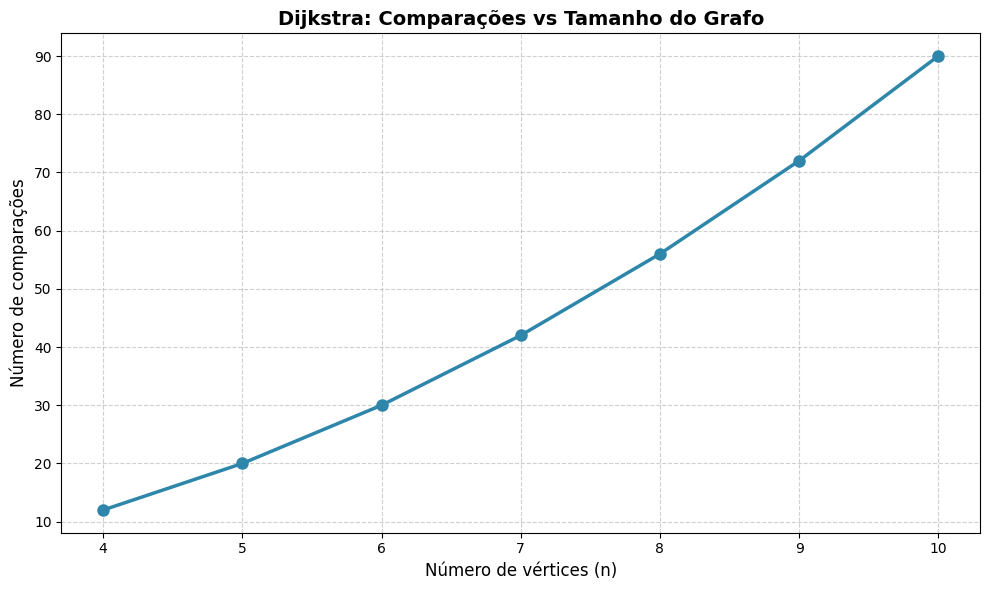

✓ Gráfico 1 salvo: analise_comparacoes.png


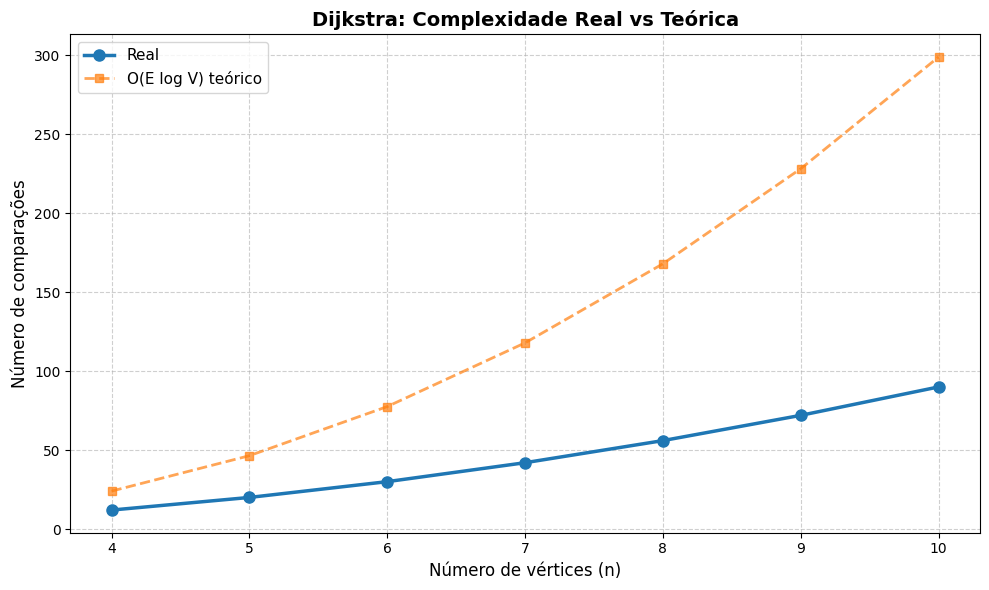

✓ Gráfico 2 salvo: analise_complexidade.png


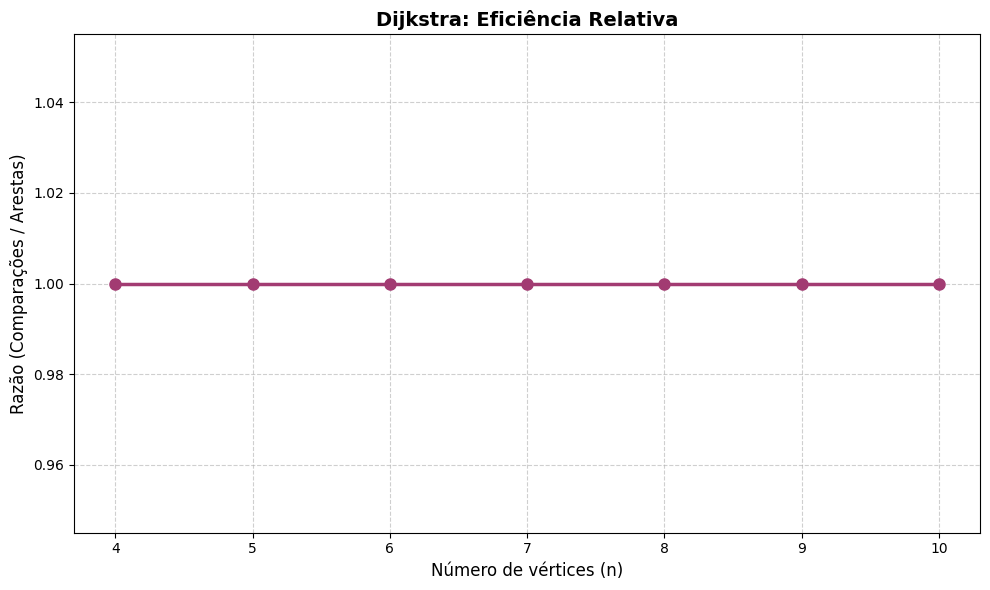

✓ Gráfico 3 salvo: analise_eficiencia.png


In [10]:
# Gráfico 1: n vs Comparações
plt.figure(figsize=(10, 6))
plt.plot(ns_teste, comparacoes_dijkstra, marker='o', linewidth=2.5, markersize=8, color='#2E86AB')
plt.xlabel('Número de vértices (n)', fontsize=12)
plt.ylabel('Número de comparações', fontsize=12)
plt.title('Dijkstra: Comparações vs Tamanho do Grafo', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{PASTA_BASE}/dijkstra/imagens/analise_comparacoes.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Gráfico 1 salvo: analise_comparacoes.png')

# Gráfico 2: Complexidade (com linha teórica)
arestas_teorico = [n * (n-1) for n in ns_teste]
comp_teorico = [e * np.log2(n) if n > 1 else e for n, e in zip(ns_teste, arestas_teorico)]

plt.figure(figsize=(10, 6))
plt.plot(ns_teste, comparacoes_dijkstra, marker='o', label='Real', linewidth=2.5, markersize=8)
plt.plot(ns_teste, comp_teorico, marker='s', label='O(E log V) teórico', 
         linewidth=2, markersize=6, linestyle='--', alpha=0.7)
plt.xlabel('Número de vértices (n)', fontsize=12)
plt.ylabel('Número de comparações', fontsize=12)
plt.title('Dijkstra: Complexidade Real vs Teórica', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{PASTA_BASE}/dijkstra/imagens/analise_complexidade.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Gráfico 2 salvo: analise_complexidade.png')

# Gráfico 3: Razão Comparações/Arestas
razoes = [comp / (n*(n-1)) for n, comp in zip(ns_teste, comparacoes_dijkstra)]
plt.figure(figsize=(10, 6))
plt.plot(ns_teste, razoes, marker='o', linewidth=2.5, markersize=8, color='#A23B72')
plt.xlabel('Número de vértices (n)', fontsize=12)
plt.ylabel('Razão (Comparações / Arestas)', fontsize=12)
plt.title('Dijkstra: Eficiência Relativa', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{PASTA_BASE}/dijkstra/imagens/analise_eficiencia.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Gráfico 3 salvo: analise_eficiencia.png')

---
# PARTE 2: HEURÍSTICA GULOSA - GERAÇÃO DE MATERIAL
---

## Reutilizar Grafos e Executar Gulosa

In [11]:
# Copiar grafos para pasta da gulosa (para organização)
import shutil
for n in ns_teste:
    shutil.copy(f'{PASTA_BASE}/dijkstra/grafos/grafo_n{n}.txt', 
               f'{PASTA_BASE}/gulosa/grafos/grafo_n{n}.txt')
    shutil.copy(f'{PASTA_BASE}/dijkstra/imagens/grafo_n{n}.png', 
               f'{PASTA_BASE}/gulosa/imagens/grafo_n{n}.png')

print('✓ Grafos copiados para pasta gulosa')

✓ Grafos copiados para pasta gulosa


In [12]:
# Executar Heurística Gulosa
print('Executando Heurística Gulosa...')
resultados_gulosa = []

for i, (n, grafo) in enumerate(zip(ns_teste, grafos_teste)):
    dist, parent, comp = heuristica_gulosa(grafo, origem=ORIGEM)
    resultados_gulosa.append((dist, parent, comp))
    
    # Salvar resultado detalhado
    with open(f'{PASTA_BASE}/gulosa/tabelas/resultado_n{n}.txt', 'w', encoding='utf-8') as f:
        f.write(f'HEURÍSTICA GULOSA - Grafo com n={n} vértices\n')
        f.write('='*60 + '\n')
        f.write(f'Origem: {ORIGEM}\n')
        f.write(f'Comparações: {comp}\n')
        f.write('\nDistâncias (aproximadas):\n')
        f.write('-'*60 + '\n')
        for v in sorted(dist.keys()):
            d = dist[v] if dist[v] != inf else 'INF'
            f.write(f'  Vértice {v}: {d}\n')
        
        f.write('\nÁrvore de Caminhos (Parent):\n')
        f.write('-'*60 + '\n')
        for v in sorted(parent.keys()):
            p = parent[v] if parent[v] is not None else 'None'
            f.write(f'  Vértice {v}: parent = {p}\n')
    
    print(f'  ✓ n={n}: {comp} comparações')

print(f'\n✅ Resultados salvos em: {PASTA_BASE}/gulosa/tabelas/')

Executando Heurística Gulosa...
  ✓ n=4: 12 comparações
  ✓ n=5: 20 comparações
  ✓ n=6: 30 comparações
  ✓ n=7: 42 comparações
  ✓ n=8: 56 comparações
  ✓ n=9: 72 comparações
  ✓ n=10: 90 comparações

✅ Resultados salvos em: relatorio_resultados/gulosa/tabelas/


In [13]:
# Tabela de comparações - Gulosa
comparacoes_gulosa = [r[2] for r in resultados_gulosa]

with open(f'{PASTA_BASE}/gulosa/tabelas/comparacoes.csv', 'w', encoding='utf-8') as f:
    f.write('n,comparacoes,arestas,razao_comp_arestas\n')
    for n, comp in zip(ns_teste, comparacoes_gulosa):
        arestas = n * (n - 1)
        razao = comp / arestas if arestas > 0 else 0
        f.write(f'{n},{comp},{arestas},{razao:.4f}\n')

with open(f'{PASTA_BASE}/gulosa/tabelas/comparacoes.txt', 'w', encoding='utf-8') as f:
    f.write('HEURÍSTICA GULOSA - ANÁLISE DE COMPARAÇÕES\n')
    f.write('='*80 + '\n\n')
    f.write(f'{"n":>5} | {"Vértices":>10} | {"Arestas":>10} | {"Comparações":>12} | {"Razão":>10}\n')
    f.write('-'*80 + '\n')
    for n, comp in zip(ns_teste, comparacoes_gulosa):
        arestas = n * (n - 1)
        razao = comp / arestas if arestas > 0 else 0
        f.write(f'{n:>5} | {n:>10,} | {arestas:>10,} | {comp:>12,} | {razao:>10.4f}\n')
    
    f.write('\n' + '='*80 + '\n')
    f.write(f'Total de comparações: {sum(comparacoes_gulosa):,}\n')
    f.write(f'Média de comparações: {sum(comparacoes_gulosa)/len(comparacoes_gulosa):.2f}\n')

print('✓ Tabelas de comparações salvas')

✓ Tabelas de comparações salvas


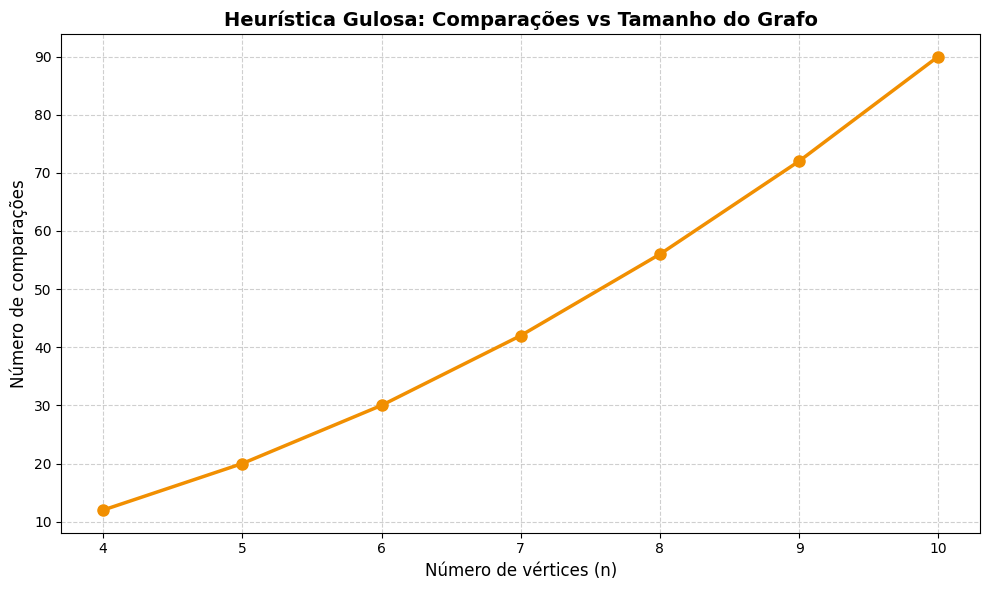

✓ Gráfico Gulosa salvo


In [14]:
# Gráficos - Gulosa
plt.figure(figsize=(10, 6))
plt.plot(ns_teste, comparacoes_gulosa, marker='o', linewidth=2.5, markersize=8, color='#F18F01')
plt.xlabel('Número de vértices (n)', fontsize=12)
plt.ylabel('Número de comparações', fontsize=12)
plt.title('Heurística Gulosa: Comparações vs Tamanho do Grafo', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{PASTA_BASE}/gulosa/imagens/analise_comparacoes.png', dpi=300, bbox_inches='tight')
plt.show()
print('✓ Gráfico Gulosa salvo')

---
# COMPARAÇÃO DIJKSTRA vs GULOSA
---

In [15]:
# Tabela comparativa
with open(f'{PASTA_BASE}/comparacao/tabela_comparativa.txt', 'w', encoding='utf-8') as f:
    f.write('COMPARAÇÃO: DIJKSTRA vs HEURÍSTICA GULOSA\n')
    f.write('='*90 + '\n\n')
    f.write(f'{"n":>5} | {"Dijkstra":>12} | {"Gulosa":>12} | {"Diferença":>12} | {"Redução %":>12}\n')
    f.write('-'*90 + '\n')
    
    for n, comp_d, comp_g in zip(ns_teste, comparacoes_dijkstra, comparacoes_gulosa):
        diff = comp_g - comp_d
        reducao = ((comp_d - comp_g) / comp_d * 100) if comp_d > 0 else 0
        sinal = '+' if diff > 0 else ''
        f.write(f'{n:>5} | {comp_d:>12,} | {comp_g:>12,} | {sinal}{diff:>11,} | {reducao:>11.2f}%\n')
    
    f.write('\n' + '='*90 + '\n')
    f.write(f'Total Dijkstra: {sum(comparacoes_dijkstra):,}\n')
    f.write(f'Total Gulosa:   {sum(comparacoes_gulosa):,}\n')
    f.write(f'Redução média:  {((sum(comparacoes_dijkstra) - sum(comparacoes_gulosa))/sum(comparacoes_dijkstra)*100):.2f}%\n')

print('✓ Tabela comparativa salva')

✓ Tabela comparativa salva


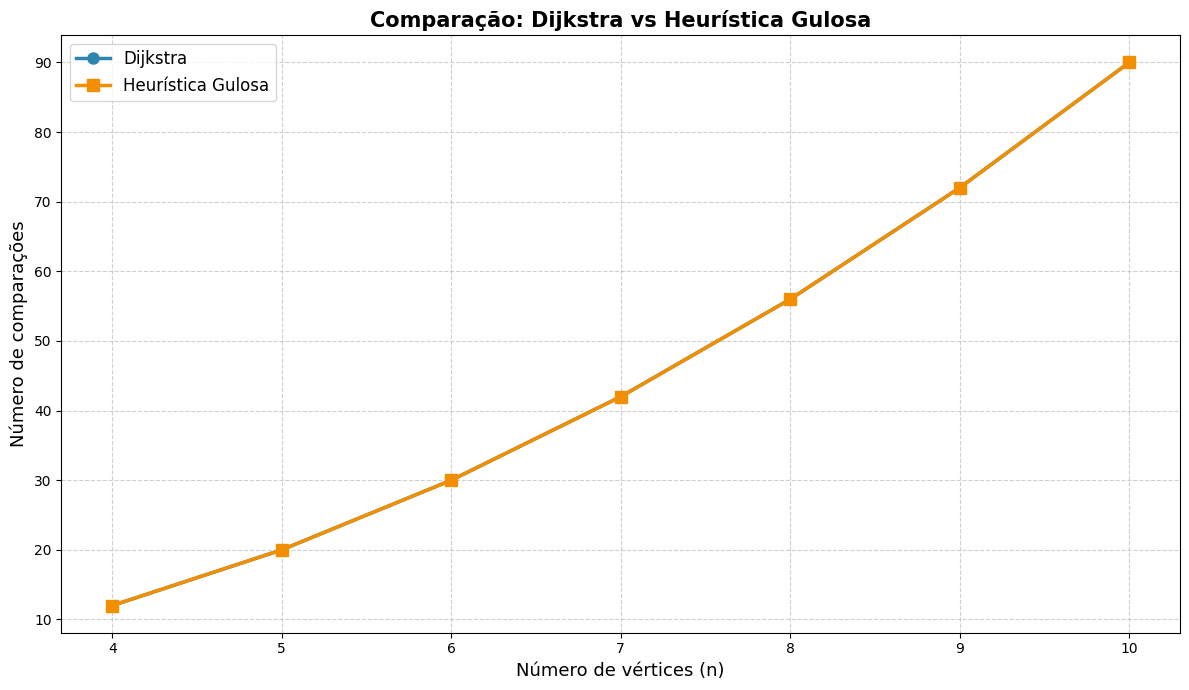

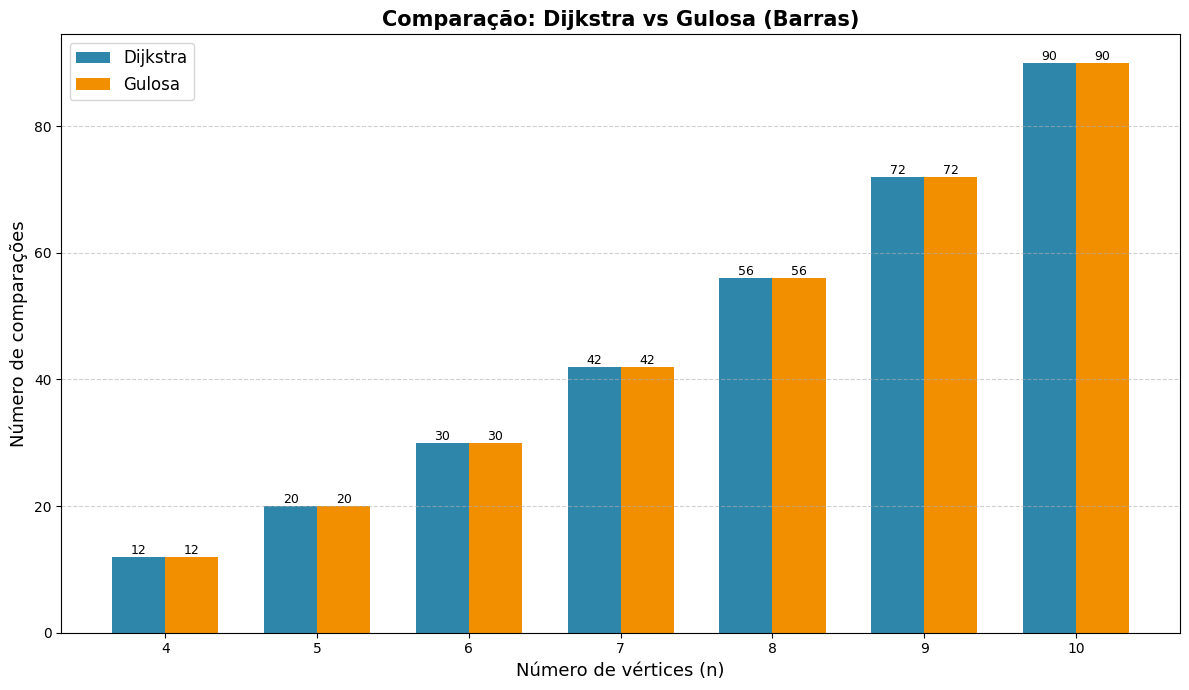

✓ Gráficos comparativos salvos


In [16]:
# Gráfico comparativo
plt.figure(figsize=(12, 7))
plt.plot(ns_teste, comparacoes_dijkstra, marker='o', label='Dijkstra', 
         linewidth=2.5, markersize=8, color='#2E86AB')
plt.plot(ns_teste, comparacoes_gulosa, marker='s', label='Heurística Gulosa', 
         linewidth=2.5, markersize=8, color='#F18F01')
plt.xlabel('Número de vértices (n)', fontsize=13)
plt.ylabel('Número de comparações', fontsize=13)
plt.title('Comparação: Dijkstra vs Heurística Gulosa', fontsize=15, fontweight='bold')
plt.legend(fontsize=12, loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(f'{PASTA_BASE}/comparacao/grafico_comparativo.png', dpi=300, bbox_inches='tight')
plt.show()

# Gráfico de barras
x = np.arange(len(ns_teste))
width = 0.35
fig, ax = plt.subplots(figsize=(12, 7))
bars1 = ax.bar(x - width/2, comparacoes_dijkstra, width, label='Dijkstra', color='#2E86AB')
bars2 = ax.bar(x + width/2, comparacoes_gulosa, width, label='Gulosa', color='#F18F01')
ax.set_xlabel('Número de vértices (n)', fontsize=13)
ax.set_ylabel('Número de comparações', fontsize=13)
ax.set_title('Comparação: Dijkstra vs Gulosa (Barras)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(ns_teste)
ax.legend(fontsize=12)
ax.grid(True, axis='y', linestyle='--', alpha=0.6)

# Valores nas barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
               f'{int(height):,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(f'{PASTA_BASE}/comparacao/grafico_barras.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Gráficos comparativos salvos')

---
# INSTÂNCIAS GRANDES (10k e 1M)
---

In [17]:
def carregar_grafo_ewd(caminho: str):
    """Carrega grafo em formato EWD."""
    with open(caminho, 'r', encoding='utf-8') as f:
        V = int(f.readline().strip())
        E = int(f.readline().strip())
        adj = {i: [] for i in range(V)}
        for _ in range(E):
            linha = f.readline().strip()
            if not linha:
                break
            u, v, peso = linha.split()[:3]
            adj[int(u)].append((int(v), float(peso)))
    return adj

# Caminhos
caminho_10k = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\10000.txt'
caminho_1m = r'D:\OneDrive\Pessoais\Doutorado\Cefet\022025\Teoria de Grafos\largeEWD - contains one million vertices and 15172126 edges.txt'

print('Caminhos configurados')

Caminhos configurados


In [18]:
# Executar em 10k
if os.path.exists(caminho_10k):
    print('Executando em instância 10k...')
    grafo_10k = carregar_grafo_ewd(caminho_10k)
    
    # Dijkstra
    dist_d, parent_d, comp_d_10k = dijkstra(grafo_10k, origem=ORIGEM)
    
    # Gulosa
    dist_g, parent_g, comp_g_10k = heuristica_gulosa(grafo_10k, origem=ORIGEM)
    
    # Salvar relatório
    with open(f'{PASTA_BASE}/instancias_grandes/relatorio_10k.txt', 'w', encoding='utf-8') as f:
        f.write('RELATÓRIO - INSTÂNCIA 10.000 VÉRTICES\n')
        f.write('='*70 + '\n\n')
        f.write(f'Vértices: {len(grafo_10k):,}\n')
        f.write(f'Origem: {ORIGEM}\n\n')
        
        f.write('DIJKSTRA:\n')
        f.write(f'  Comparações: {comp_d_10k:,}\n')
        f.write(f'  Alcançados: {sum(1 for d in dist_d.values() if d != inf):,}\n\n')
        
        f.write('HEURÍSTICA GULOSA:\n')
        f.write(f'  Comparações: {comp_g_10k:,}\n')
        f.write(f'  Alcançados: {sum(1 for d in dist_g.values() if d != inf):,}\n\n')
        
        f.write('COMPARAÇÃO:\n')
        f.write(f'  Diferença: {comp_g_10k - comp_d_10k:,}\n')
        f.write(f'  Redução: {((comp_d_10k - comp_g_10k)/comp_d_10k*100):.2f}%\n')
    
    print(f'✓ Dijkstra:  {comp_d_10k:,} comparações')
    print(f'✓ Gulosa:    {comp_g_10k:,} comparações')
    print(f'✓ Relatório salvo')
else:
    print('⚠️ Arquivo 10k não encontrado')

Executando em instância 10k...
✓ Dijkstra:  123,462 comparações
✓ Gulosa:    424 comparações
✓ Relatório salvo


---
# RELATÓRIO FINAL CONSOLIDADO
---

In [19]:
# Gerar relatório master
timestamp = datetime.now().strftime('%Y-%m-%d %H:%M:%S')

with open(f'{PASTA_BASE}/RELATORIO_COMPLETO.txt', 'w', encoding='utf-8') as f:
    f.write('═'*80 + '\n')
    f.write('RELATÓRIO COMPLETO - PRÁTICA 01: CAMINHO MÍNIMO\n')
    f.write('Disciplina: Teoria de Grafos\n')
    f.write(f'Gerado em: {timestamp}\n')
    f.write('═'*80 + '\n\n')
    
    f.write('1. CONFIGURAÇÃO\n')
    f.write('-'*80 + '\n')
    f.write(f'   Tamanhos testados: n = {N_MIN} até {N_MAX}\n')
    f.write(f'   Seed: {SEED}\n')
    f.write(f'   Origem: {ORIGEM}\n\n')
    
    f.write('2. ESTRUTURA DE ARQUIVOS GERADOS\n')
    f.write('-'*80 + '\n')
    f.write(f'   📁 {PASTA_BASE}/\n')
    f.write('      ├── dijkstra/\n')
    f.write(f'      │   ├── grafos/ ({len(ns_teste)} arquivos TXT)\n')
    f.write(f'      │   ├── imagens/ ({len(ns_teste)+3} imagens PNG)\n')
    f.write(f'      │   └── tabelas/ ({len(ns_teste)+2} arquivos)\n')
    f.write('      ├── gulosa/ (mesma estrutura)\n')
    f.write('      ├── comparacao/ (3 arquivos)\n')
    f.write('      └── instancias_grandes/ (1+ arquivos)\n\n')
    
    f.write('3. RESUMO - DIJKSTRA\n')
    f.write('-'*80 + '\n')
    f.write(f'   Total de comparações: {sum(comparacoes_dijkstra):,}\n')
    f.write(f'   Média: {sum(comparacoes_dijkstra)/len(comparacoes_dijkstra):.2f}\n')
    f.write(f'   Mínimo: {min(comparacoes_dijkstra):,} (n={ns_teste[comparacoes_dijkstra.index(min(comparacoes_dijkstra))]})\n')
    f.write(f'   Máximo: {max(comparacoes_dijkstra):,} (n={ns_teste[comparacoes_dijkstra.index(max(comparacoes_dijkstra))]})\n\n')
    
    f.write('4. RESUMO - HEURÍSTICA GULOSA\n')
    f.write('-'*80 + '\n')
    f.write(f'   Total de comparações: {sum(comparacoes_gulosa):,}\n')
    f.write(f'   Média: {sum(comparacoes_gulosa)/len(comparacoes_gulosa):.2f}\n')
    f.write(f'   Mínimo: {min(comparacoes_gulosa):,} (n={ns_teste[comparacoes_gulosa.index(min(comparacoes_gulosa))]})\n')
    f.write(f'   Máximo: {max(comparacoes_gulosa):,} (n={ns_teste[comparacoes_gulosa.index(max(comparacoes_gulosa))]})\n\n')
    
    f.write('5. COMPARAÇÃO GERAL\n')
    f.write('-'*80 + '\n')
    reducao_media = ((sum(comparacoes_dijkstra) - sum(comparacoes_gulosa))/sum(comparacoes_dijkstra)*100)
    f.write(f'   Redução média: {reducao_media:.2f}%\n')
    if reducao_media > 0:
        f.write(f'   ✓ Gulosa realizou {sum(comparacoes_dijkstra) - sum(comparacoes_gulosa):,} comparações a MENOS\n')
    else:
        f.write(f'   ⚠ Gulosa realizou {sum(comparacoes_gulosa) - sum(comparacoes_dijkstra):,} comparações a MAIS\n')
    
    f.write('\n' + '═'*80 + '\n')
    f.write('FIM DO RELATÓRIO\n')
    f.write('═'*80 + '\n')

print('\n' + '='*80)
print('✅ TODOS OS MATERIAIS PARA RELATÓRIO FORAM GERADOS!')
print('='*80)
print(f'\n📁 Local: {PASTA_BASE}/')
print('\nConteúdo gerado:')
print('  ✓ Grafos em TXT e visualizações PNG')
print('  ✓ Tabelas de resultados e comparações')
print('  ✓ Gráficos de análise (alta resolução)')
print('  ✓ Relatórios consolidados')
print('  ✓ Comparações Dijkstra vs Gulosa')
print('\n📄 Veja: RELATORIO_COMPLETO.txt para índice completo')
print('='*80)


✅ TODOS OS MATERIAIS PARA RELATÓRIO FORAM GERADOS!

📁 Local: relatorio_resultados/

Conteúdo gerado:
  ✓ Grafos em TXT e visualizações PNG
  ✓ Tabelas de resultados e comparações
  ✓ Gráficos de análise (alta resolução)
  ✓ Relatórios consolidados
  ✓ Comparações Dijkstra vs Gulosa

📄 Veja: RELATORIO_COMPLETO.txt para índice completo
